In [617]:
# Libraries used
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Q1: Data Cleaning and Preprocessing (4 points)

In [618]:
# 1. Load the dataset into a Pandas DataFrame. Refer to the Pandas manual and select the appropriate method to load the file.
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
before_cleaning = len(df)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [619]:
# just checking
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [620]:
# just checking
duplicate1 = df.iloc[600]
duplicate2 = df.iloc[597]
no_customer = df.iloc[622]
no_desc = df.iloc[1970]
# print(f"{duplicate1}\n")
# print(f"{duplicate2}\n")
# print(f"{no_customer}\n")
# print(f"{no_desc}\n")

testing_df = pd.DataFrame([duplicate1, duplicate2, no_customer, no_desc])

# testing_df = testing_df.drop_duplicates()
# testing_df = testing_df.dropna(subset=['CustomerID'])
# testing_df['Description'] = testing_df['Description'].fillna("Unknown Product")
# testing_df['Description'] = testing_df['Description'].replace(np.nan, "Unknown Product")
testing_df.loc[:, 'Description'] = testing_df['Description'].fillna("Unknown Product")
testing_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,12/1/2010 11:49,3.75,17920.0,United Kingdom
597,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,12/1/2010 11:49,3.75,17920.0,United Kingdom
622,536414,22139,Unknown Product,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1970,536545,21134,Unknown Product,1,12/1/2010 14:32,0.00,NaN,United Kingdom


In [621]:
# 2. Remove duplicate rows from the dataset.
df = df.drop_duplicates()
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [622]:
# 3. Drop rows where CustomerID is missing.
df = df.dropna(subset=['CustomerID'])
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [623]:
# 4. Fill missing Description values with "Unknown Product".
df.loc[:, 'Description'] = df['Description'].fillna("Unknown Product")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [624]:
# 5. Ensure all values in the Description column are in lowercase.
df.loc[:, 'Description'] = df['Description'].str.lower()
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,white hanging heart t-light holder,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,white metal lantern,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,cream cupid hearts coat hanger,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,knitted union flag hot water bottle,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,red woolly hottie white heart.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,pack of 20 spaceboy napkins,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,children's apron dolly girl,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,childrens cutlery dolly girl,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,childrens cutlery circus parade,4,12/9/2011 12:50,4.15,12680.0,France


In [625]:
# 6. Print the number of rows before and after cleaning.
print(f"🔢 Number of rows before cleaning: {before_cleaning}")
print(f"🧹 Number of rows after cleaning: {len(df)}")

🔢 Number of rows before cleaning: 541909
🧹 Number of rows after cleaning: 401604


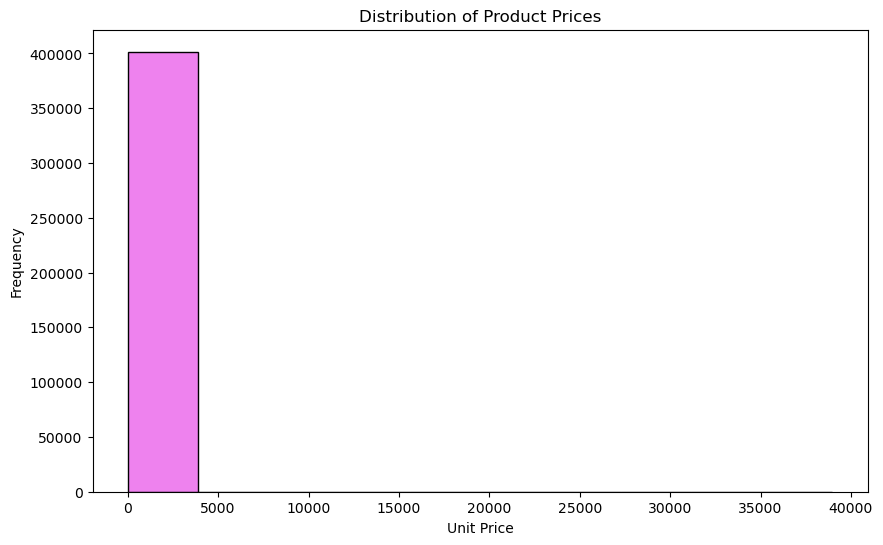

In [626]:
# 7. Create a histogram of UnitPrice values to show the distribution of product prices.
plt.figure(figsize=(10, 6))
plt.hist(df['UnitPrice'], edgecolor='black', color='violet')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.title('Distribution of Product Prices')
plt.show()

In [627]:
# # Extra: Histogram
# bin_width = 2.00

# min_price = df['UnitPrice'].min()
# max_price = df['UnitPrice'].max()

# # bins = np.arange(min_price, max_price + bin_width, bin_width)

# bins = [0.00, 2.00, 4.00, 6.00, 8.00, 10.00, 12.00, 14.00]
# df = df.copy()
# df.loc[:, 'PriceRange'] = pd.cut(df['UnitPrice'], bins=bins)
# grouped = df.groupby('PriceRange', observed=False)['Quantity'].sum().reset_index()

# # Plot the histogram
# plt.bar(grouped['PriceRange'].astype(str), grouped['Quantity'], color='blue', edgecolor='black')
# plt.xlabel('UnitPrice Range')
# plt.ylabel('Quantity (Frequency)')
# plt.title('Histogram of UnitPrice Distribution')
# plt.xticks(rotation=45)
# plt.show()

###  Q2: Data Aggregation and Sales Analysis (2.5 points)

In [628]:
# 1. Create a new column TotalRevenue, where: TotalRevenue = Quantity × UnitPrice
df = df.copy()
df.loc[:, 'TotalRevenue'] = df['Quantity'] * df['UnitPrice']

In [629]:
# 2. Find the top 5 best-selling products (based on total quantity sold).
best_selling_5 = df.groupby('Description')['Quantity'].sum().nlargest(5)

print("Top 5 Best-Selling Products:")
best_selling_5

Top 5 Best-Selling Products:


Description
world war 2 gliders asstd designs     53119
jumbo bag red retrospot               44963
assorted colour bird ornament         35215
white hanging heart t-light holder    34128
pack of 72 retrospot cake cases       33386
Name: Quantity, dtype: int64

In [630]:
# 3. Find the top 5 highest revenue-generating products (based on TotalRevenue).
highest_revenue_5 = df.groupby('Description')['TotalRevenue'].sum().nlargest(5)

print("Top 5 Highest Revenue-Generating Products:")
highest_revenue_5

Top 5 Highest Revenue-Generating Products:


Description
regency cakestand 3 tier              132567.70
white hanging heart t-light holder     93767.80
jumbo bag red retrospot                83056.52
party bunting                          67628.43
postage                                66710.24
Name: TotalRevenue, dtype: float64

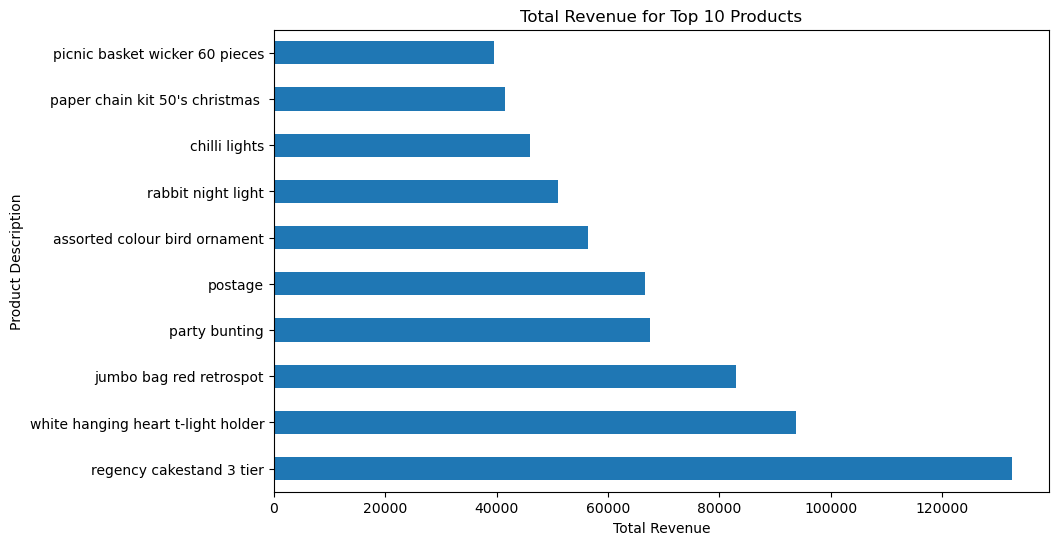

In [631]:
# 4. Create a bar chart showing total revenue for the top 10 products.
top_10_revenue_products = df.groupby('Description')['TotalRevenue'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
top_10_revenue_products.plot(kind='barh')
plt.title('Total Revenue for Top 10 Products')
plt.ylabel('Product Description')
plt.xlabel('Total Revenue')
plt.show()

### Q3: Data Visualization - Sales Trends (3.5 points)

In [632]:
# 1. Create a new column Year to represent the year of the order.
year = pd.to_datetime(df['InvoiceDate']).dt.year
df.loc[:, 'Year'] = year
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalRevenue,Year
0,536365,85123A,white hanging heart t-light holder,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,2010
1,536365,71053,white metal lantern,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,2010
2,536365,84406B,cream cupid hearts coat hanger,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,2010
3,536365,84029G,knitted union flag hot water bottle,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,2010
4,536365,84029E,red woolly hottie white heart.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,2010
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,pack of 20 spaceboy napkins,12,12/9/2011 12:50,0.85,12680.0,France,10.20,2011
541905,581587,22899,children's apron dolly girl,6,12/9/2011 12:50,2.10,12680.0,France,12.60,2011
541906,581587,23254,childrens cutlery dolly girl,4,12/9/2011 12:50,4.15,12680.0,France,16.60,2011
541907,581587,23255,childrens cutlery circus parade,4,12/9/2011 12:50,4.15,12680.0,France,16.60,2011


In [633]:
# 2. Compute total revenue in each year.
yearly_revenue = df.groupby('Year')['TotalRevenue'].sum()

print("Total Revenue in Each Year:")
yearly_revenue

Total Revenue in Each Year:


Year
2010     552372.860
2011    7726146.564
Name: TotalRevenue, dtype: float64

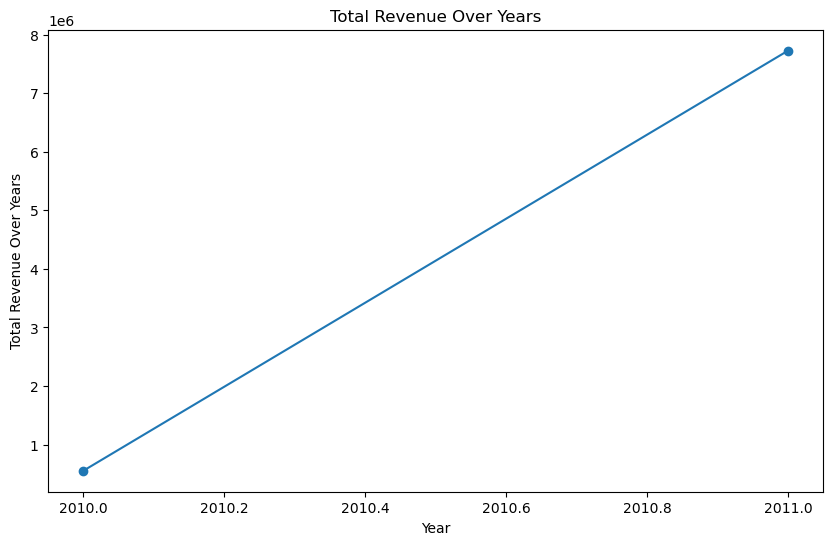

In [634]:
# 3. Create a line plot showing total revenue over each year.
plt.figure(figsize=(10, 6))
yearly_revenue.plot(kind='line', marker='o')
plt.title('Total Revenue Over Years')
plt.xlabel('Year')
plt.ylabel('Total Revenue Over Years')
plt.show()

In [635]:
# 4. Find the top 5 countries with the highest total revenue.
contries_5_hightest = df.groupby('Country')['TotalRevenue'].sum().nlargest(5)
print("Top 5 Countries by Total Revenue:")
contries_5_hightest

Top 5 Countries by Total Revenue:


Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Name: TotalRevenue, dtype: float64

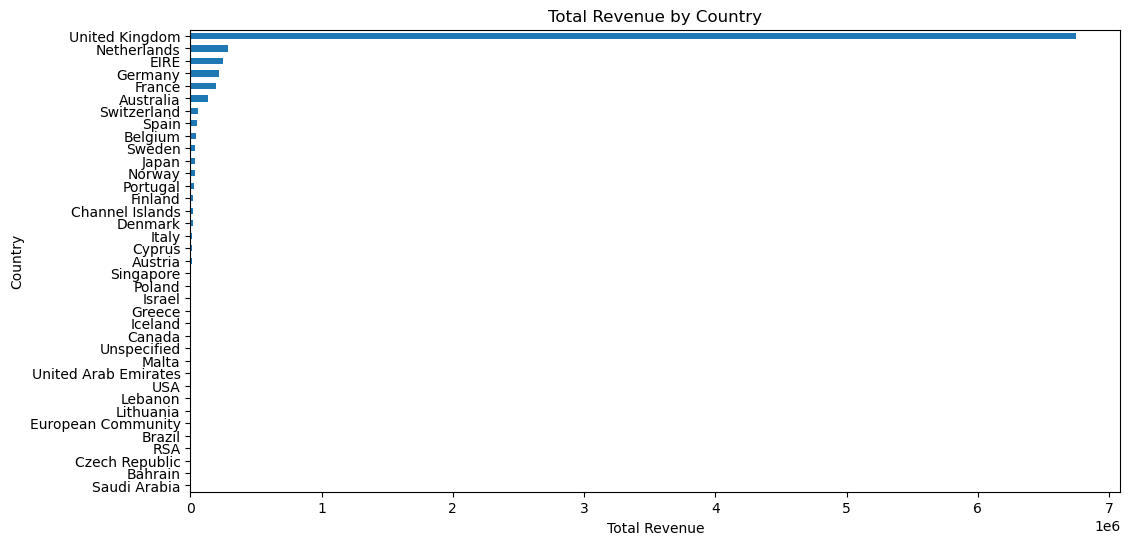

In [636]:
# 5. Create a bar chart showing total revenue per country.
plt.figure(figsize=(12, 6))
df.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=True).plot(kind='barh')
plt.title('Total Revenue by Country')
plt.ylabel('Country')
plt.xlabel('Total Revenue')
plt.show()

### Q4: Customer Spending & Relationship Analysis (5 points)

In [637]:
# 1. Calculate total revenue per customer (sum of TotalRevenue for each CustomerID).
customer_revenue = df.groupby('CustomerID')['TotalRevenue'].sum()

print("Total Revenue Per Custumer:")
customer_revenue

Total Revenue Per Custumer:


CustomerID
12346.0       0.00
12347.0    4310.00
12348.0    1797.24
12349.0    1757.55
12350.0     334.40
            ...   
18280.0     180.60
18281.0      80.82
18282.0     176.60
18283.0    2045.53
18287.0    1837.28
Name: TotalRevenue, Length: 4372, dtype: float64

In [638]:
# 2. Calculate purchase frequency per customer (number of transactions per customer).
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

print("Purchase Frequency Per Customer:")
purchase_frequency

Purchase Frequency Per Customer:


CustomerID
12346.0     2
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     3
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4372, dtype: int64

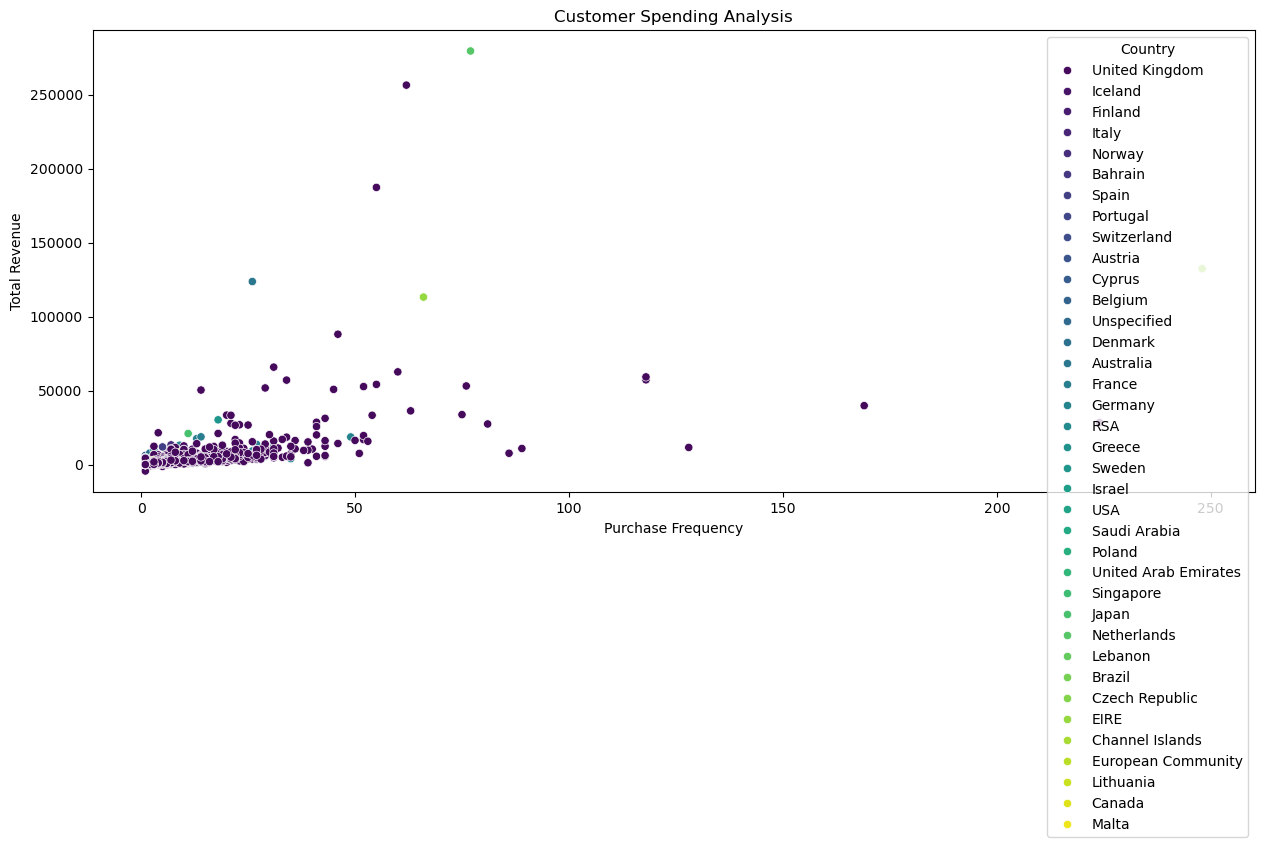

In [639]:
'''
3. Create a scatter plot using results from the previous two questions, where:
X-axis = Purchase Frequency
Y-axis = Total Revenue
Use color (hue) to distinguish customers by country.
'''

customer_data = pd.DataFrame({
    'TotalRevenue': customer_revenue,
    'PurchaseFrequency': purchase_frequency,
    'Country': df.groupby('CustomerID')['Country'].first()
})

plt.figure(figsize=(15, 6))
sns.scatterplot(data=customer_data, x='PurchaseFrequency', y='TotalRevenue', hue='Country', palette='viridis')
plt.title('Customer Spending Analysis')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Revenue')
plt.show()

In [640]:
df['TotalRevenue'] = customer_revenue
df['PurchaseFrequency'] = purchase_frequency

# 4. Select numerical columns (Quantity, UnitPrice, TotalRevenue, and Purchase Frequency). Compute the correlation matrix using df.corr().
numerical_columns = ['Quantity', 'UnitPrice', 'TotalRevenue', 'PurchaseFrequency']
correlation_matrix = df[numerical_columns].corr()

print("Correlation Matrix: ")
correlation_matrix

Correlation Matrix: 


,Quantity,UnitPrice,TotalRevenue,PurchaseFrequency
Quantity,1.000000,-0.001243,-0.005911,-0.016229
UnitPrice,-0.001243,1.000000,-0.005136,-0.002525
TotalRevenue,-0.005911,-0.005136,1.000000,0.533555
PurchaseFrequency,-0.016229,-0.002525,0.533555,1.000000


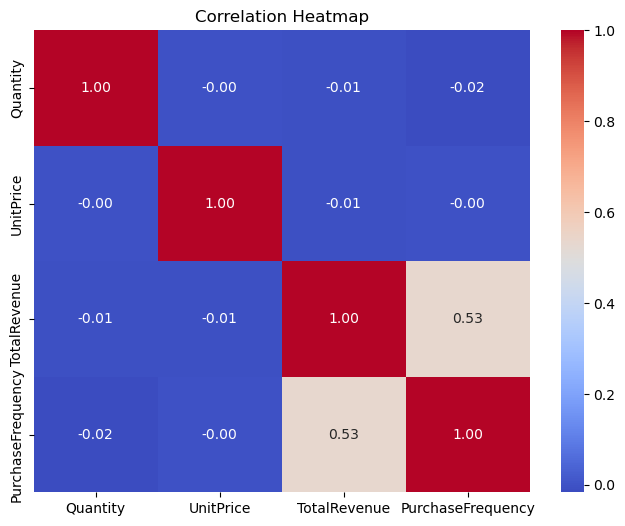

In [641]:
# 5. Create a heatmap to visualize the correlation between these features.
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()